In [1]:
from pathlib import Path
import pandas as pd
from diffusion_encoder import build_conditional_unet_1d
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


I0000 00:00:1779107302.748734   63564 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-DiffGAN-v4.7.1"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: GAN v4.7 (Gaussian Dynamic Masking, Randomized Eraser & Spectral/STFT Loss / SOTA Referanslı GAN)
Diffusion Model
MİMARİ ÖZETİ VE "DİNAMİK KÖRLEŞTİRME" MANTIĞI:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Rastgele Körleştirilmiş Sinyal (Z-Score), Gaussian Peak Maskesi]
   - Latent Boyutu: 512'den 128'e düşürülerek bilgi darboğazı (bottleneck) daraltıldı. Modelin arka plandaki gereksiz detayları ezberlemesi engellendi, sadece saf "Stil DNA'sı"na odaklanması sağlandı.
   - Latent Noise: Encoder'dan çıkan 128 boyutlu DNA'ya eğitim sırasında suni gürültü (std=0.1) eklenerek Latent Space (Gizli Uzay) pürüzsüzleştirildi. Jeneratörün ezberciliği kırıldı.
   - KRİTİK GÜNCELLEME (Randomized Eraser): Sabit boyutlu (61 birimlik) silgi mantığı tamamen terk edildi. Bunun yerine, adım şablonunun sağından ve solundan rastgele (20-80 birim) taşan, her iterasyonda boyutu dinamik olarak değişen "Rastgele Dev Silgi (enc_mask)" DataLoader içerisine entegre edildi. Modelin boşluğu ezberleme (leakage) ihtimali sıfırlandı.

2. GENERATOR (Sentezleyici):
   - Girdi: [Gürültülü z_encoded (Stil DNA'sı), Gaussian Peak Maskesi (Şablon)]
   - Görevi: Hedef şablona bakarak yürüme adımını dinamik olarak sentezlemek ve arka planla kaynaştırmak.
   - KRİTİK GÜNCELLEME (Spectral/STFT Loss): Jeneratör artık sadece zaman (waveform) ekseninde değil, FREKANS (spektrogram) ekseninde de cezalandırılıyor. Üretilen sinyal ile orijinal hedefin frekans haritaları (Short-Time Fourier Transform) üzerinden karşılaştırılıyor. Bu sayede model, adım seslerinin akustik dokusunu, tınısını ve sürtünme izlerini (dikey frekans patlamalarını) milisaniyesi milisaniyesine kopyalamayı öğreniyor.
   - KRİTİK GÜNCELLEME (Soft Gaussian Masking): Hedef şablon (peak_mask) artık sert kenarlı (binary) kutular yerine, merkeze doğru güçlenen ve uçlara doğru yumuşakça sönen bir Çan Eğrisi (Gaussian Window) olarak veriliyor. Bu sayede Jeneratör, ürettiği adımı sessizliğe "fade-in/fade-out" yaparak pürüzsüzce yedirmeyi öğreniyor, sert sınırların yarattığı yapay iğne zıplamaları (artifacts) engelleniyor.
   - Dynamic Physical Loss: Fiziksel kurallar (L_amp, L_energy, L_grad, L_stft) doğrudan bu yumuşak Gaussian maskenin sınırları içine uygulanıyor. Maske merkezinde enerji tavan yaparken, maske sönümlendikçe enerji doğal bir şekilde (ring-down) azalıyor.

3. DISCRIMINATOR (Koşullu Hakem):
   - Girdi: [Tam Sinyal + Instance Noise (std=0.05), Gaussian Peak Maskesi]
   - Görevi: Sinyalin gerçekçi bir sismik titreşim olup olmadığını ve yumuşak maskeyle uyumunu denetlemek. 
   - Savunmalar: TTUR (Farklı öğrenme hızları) ve Label Smoothing (0.9 / 0.1) aktif olarak Hakemin Jeneratörü ezmesini engelliyor.

VERİ VE MİMARİ FELSEFESİ:
- Karmaşık, birbiriyle çelişen kısıtlamalar terk edilerek "KISS (Keep It Simple, Stupid)" mühendislik felsefesine geçildi.
- Kopya çekmeyi önleyen dev silgi (enc_mask) ile hedefi gösteren şablon (peak_mask), modelin içine girmeden önce DataLoader seviyesinde (NumPy ile) ayrıştırıldı. TensorFlow Graph'ının üzerindeki karmaşık operasyon yükü kaldırıldı.
- Sinyal sentezlemesinde kutu gibi (square) maskeler yerine, doğadaki akustik seslerin sönümlenme fiziğine birebir uygun olan yumuşak zarflar (envelope/Gaussian) standart haline getirildi.
- Sadece Zaman (Time) eksenindeki kısıtlamaların sınırları aşılarak, Zaman-Frekans (Time-Frequency) analizine geçildi. Model sadece sinyalin şeklini değil, akustik DNA'sını da kavramaya zorlandı.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260518-DiffGAN-v4.7.1


In [3]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = "train_all_peaks.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=16,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
encoder = TimesBlock.build_encoder_v4(latent_dim=128)
generator = TimesBlock.build_generator_v4(latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=5000, latent_dim=128)
encoder.summary()
generator.summary()
diffusion_unet.summary()

I0000 00:00:1779107306.053279   63564 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13505 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Encoder_V4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input_only (InputLayer)  │ (None, 5000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 625, 64)        │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block (TimesBlock)        │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_1 (TimesBlock)      │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,112 (633.25 KB)

 Trainable params: 161,728 (631.75 KB)

...

Model: "Heavy_Conditional_Diffusion_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noisy_signal        │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ peak_mask           │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_step           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 5000, 2)   │          0 │ noisy_signal[0][… │
│ (Concatenate)       │                   │            │ peak_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │        512 │ time_step[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_style        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 5000, 64)  │        960 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     33,024 │ latent_style[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 5000, 64)  │        128 │ conv1d_1[0][0]    │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 256)       │          0 │ dense_4[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 5000, 64)  │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     16,448 │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 5000, 64)  │     20,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 5000, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 5000, 64)  │        128 │ add_11[0][0]      │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 5000, 64)  │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 5000, 64)  │     20,544 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 37,528,897 (143.16 MB)

 Trainable params: 37,528,897 (143.16 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import tensorflow as tf
# import tf_keras as keras
import tf_keras as legacy_keras
classifier = legacy_keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [6]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [7]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [8]:
def compute_stft_loss(real_sig, fake_sig, frame_length=256, frame_step=64):
    """
    Sinyallerin frekans (spektrogram) imzalarının ne kadar benzediğini hesaplar.
    Hem doğrusal genlikleri hem de logaritmik (desibel benzeri) düşük enerjileri kıyaslar.
    """
    # Girdiler (Batch, Window, 1) şeklindeyse son boyutu ezelim: (Batch, Window)
    real_sig = tf.squeeze(real_sig, axis=-1)
    fake_sig = tf.squeeze(fake_sig, axis=-1)
    
    # STFT Hesaplaması (TensorFlow'un yerleşik fonksiyonu)
    stft_real = tf.signal.stft(real_sig, frame_length=frame_length, frame_step=frame_step)
    stft_fake = tf.signal.stft(fake_sig, frame_length=frame_length, frame_step=frame_step)
    
    # Sadece büyüklükleri (Magnitude) al (Faz bilgisini çöpe atıyoruz)
    mag_real = tf.abs(stft_real)
    mag_fake = tf.abs(stft_fake)
    
    # Log-Magnitude (Düşük sönümlenme frekanslarındaki detayları kaybetmemek için)
    # log(0) hatası almamak için çok küçük bir epsilon (1e-7) ekliyoruz.
    log_mag_real = tf.math.log(mag_real + 1e-7)
    log_mag_fake = tf.math.log(mag_fake + 1e-7)
    
    # Hem güçlü vuruşlar (Linear Loss) hem de zayıf yankılar (Log Loss) için MAE (L1) hesabı
    lin_loss = tf.reduce_mean(tf.abs(mag_real - mag_fake))
    log_loss = tf.reduce_mean(tf.abs(log_mag_real - log_mag_fake))
    
    # İkisini toplayıp gönder
    return lin_loss + log_loss

In [9]:
import tensorflow as tf
unet_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
# =================================================================
# --- DİFÜZYON ZAMANLAYICISI (Eğitim scriptinin en üstüne yazılır) ---
# =================================================================
T = 1000 # Toplam difüzyon adımı
betas = tf.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alphas_cumprod = tf.math.cumprod(alphas)

@tf.function
def train_step(real_signals, peak_masks, enc_masks):
    batch_size = tf.shape(real_signals)[0]
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    
    # --- 1. ENCODER KÖRLEŞTİRME (Stil DNA'sı için) ---
    inv_masks = 1.0 - enc_masks
    masked_real_signals = real_signals_normalized * inv_masks
    concat_input = tf.concat([masked_real_signals, peak_masks], axis=-1)

    # =================================================================
    # +++ DİFÜZYON: İLERİ SÜREÇ (FORWARD PROCESS - GÜRÜLTÜ EKLEME) +++
    # =================================================================
    
    # 1. Her sinyal için rastgele bir zaman adımı (t) seç (0 ile T-1 arası)
    t = tf.random.uniform(shape=(batch_size,), minval=0, maxval=T, dtype=tf.int32)
    
    # 2. Seçilen t adımları için gürültü çarpanlarını (alpha_cumprod) çek
    a_t = tf.gather(alphas_cumprod, t)
    a_t = tf.reshape(a_t, (batch_size, 1, 1))
    
    # 3. Saf, rastgele Gauss gürültüsü üret (Epsilon)
    noise = tf.random.normal(shape=tf.shape(real_signals_normalized))
    
    # 4. Orijinal sinyali t adımına kadar gürültüyle boz (x_t)
    # Formül: x_t = sqrt(a_t) * x_0 + sqrt(1 - a_t) * noise
    noisy_signals = tf.sqrt(a_t) * real_signals_normalized + tf.sqrt(1.0 - a_t) * noise

    # =================================================================
    # +++ DİFÜZYON: GERİ SÜREÇ (REVERSE PROCESS - EĞİTİM) +++
    # =================================================================
    with tf.GradientTape() as tape:
        
        # A. Stil DNA'sını çıkar (Bunu encoder.trainable = False diyerek dondurabilirsin de)
        z_encoded = encoder(concat_input, training=True)
        
        # B. Zamanı normalize et (0-1 aralığına getir ki U-Net rahat anlasın)
        t_normalized = tf.cast(t, tf.float32) / tf.cast(T, tf.float32)
        
        # C. U-NET'TEN GÜRÜLTÜ TAHMİNİ İSTE
        # Girdiler: Bozulan Sinyal, Zaman, Stil DNA'sı, Gaussian Hedef
        pred_noise = diffusion_unet([noisy_signals, t_normalized, z_encoded, peak_masks], training=True)
        
        # D. YEPYENİ VE TERTEMİZ LOSS: Gerçek Gürültü vs Tahmin Edilen Gürültü
        loss = tf.reduce_mean(tf.square(noise - pred_noise))

    # --- OPTİMİZASYON ---
    # Discriminator çöpe gittiği için tek bir optimizer çalışıyor
    var_list = encoder.trainable_variables + diffusion_unet.trainable_variables
    grads = tape.gradient(loss, var_list)
    unet_optimizer.apply_gradients(zip(grads, var_list))
    
    # Loglamak istersen sadece bu loss'u döndürmen yeterli
    return loss

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import librosa
import librosa.display
from scipy import signal
from tqdm import tqdm # Döngü ilerlemesini görmek için

def visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, folder_path, sr=2000, T=1000):
    """
    sr (Sample Rate): DAS verinin örnekleme frekansı. Örn: 1000 Hz, 2000 Hz. 
    T (Timesteps): Difüzyon modelinin gürültü temizleme adım sayısı.
    """
    # Rastgele bir batch seç
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    # enc_mask = batch_data[0:1, :, 2:3] # Encoder körleştirme maskesi (eğer batch'te geliyorsa)
    window_size = real_sig.shape[1] 
    
    # --- SANİYE CİNSİNDEN ZAMAN EKSENİ (X-AXIS) ---
    time_axis = np.arange(window_size) / sr
    max_time = time_axis[-1] 
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    
    # --- STİL DNA'SINI ÇIKARMA (ENCODER) ---
    # Not: Eğer DataLoader'dan enc_mask geliyorsa burada onu kullanarak silme işlemi yapmalısın.
    # Şimdilik mevcut koduna sadık kalarak peak_mask üzerinden körleştiriyoruz.
    peak_mask_np = peak_mask if isinstance(peak_mask, np.ndarray) else peak_mask.numpy()
    inv_mask = 1.0 - peak_mask_np
    masked_real_sig = real_sig_norm * inv_mask
    
    encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)
    
    z_encoded = encoder(encoder_input, training=False)

    # =================================================================
    # +++ DİFÜZYON: GERİ SÜREÇ (REVERSE PROCESS - DENOISING LOOP) +++
    # =================================================================
    # Gürültü takvimini (Noise Schedule) oluştur
    betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas)
    
    # 1. Tamamen rastgele bir Gauss gürültüsü ile başla (Mermer bloğu)
    x = tf.random.normal(shape=(1, window_size, 1))
    
    print(f"Epoch {epoch+1} için sinyal sentezleniyor (Difüzyon: {T} Adım)...")
    
    # 2. T'den 0'a doğru adım adım gürültüyü yont
    for t in tqdm(reversed(range(T)), total=T, desc="Denoising"):
        # Zamanı modele uygun şekilde normalize et (0-1 arası)
        t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
        
        # U-Net'ten bu adımdaki gürültüyü tahmin etmesini iste
        pred_noise = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
        
        # Matematiksel katsayılar
        alpha_t = alphas[t]
        alpha_t_cumprod = alphas_cumprod[t]
        beta_t = betas[t]
        
        # Son adımda (t=0) ekstra gürültü eklenmez
        if t > 0:
            noise = tf.random.normal(shape=tf.shape(x))
        else:
            noise = tf.zeros_like(x)
            
        # DDPM Güncelleme Formülü (Gürültüyü sinyalden çıkar ve bir alt adıma geç)
        x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

    # Üretilen saf (denoised) sinyal
    fake_sig_norm = x

    # --- 1B FORMATINA ÇEVİR ---
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    # FİLTRELEME (EKSEN KAYMASI VE DC OFFSET TEMİZLİĞİ)
    real_1d = signal.detrend(real_1d)
    fake_1d = signal.detrend(fake_1d)
    
    # YÜKSEK ÇÖZÜNÜRLÜKLÜ SPEKTROGRAM AYARLARI
    HOP_LENGTH = 64
    N_FFT = 256
    FMIN = 10
    FMAX = sr // 2  
    DB_MIN = -50
    
    # ==========================================
    # --- ÇİZİM BÖLÜMÜ (Aynı Bırakıldı) ---
    # ==========================================
    plt.figure(figsize=(18, 16), dpi=90) 
    
    # 1. PANEL: Orijinal Waveform
    plt.subplot(4, 1, 1)
    plt.plot(time_axis, real_1d, color='gray', alpha=0.8, label='Orijinal Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(real_1d)), 
                     color='red', alpha=0.2, label='Random Peak Alanı')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Orijinal Waveform (SR: {sr} Hz)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # 2. PANEL: Orijinal Mel Spectrogram
    ax2 = plt.subplot(4, 1, 2)
    S_real = librosa.feature.melspectrogram(y=real_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_real_db = librosa.power_to_db(S_real, ref=np.max)
    img_real = librosa.display.specshow(S_real_db, x_axis='time', y_axis='mel', sr=sr, 
                                        ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                        cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Orijinal Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    
    # 3. PANEL: Yapay Waveform
    plt.subplot(4, 1, 3)
    plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(fake_1d)), 
                     color='red', alpha=0.2, label='Jeneratör Hedefi')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Yapay Waveform (SR: {sr} Hz)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # 4. PANEL: Yapay Mel Spectrogram
    ax4 = plt.subplot(4, 1, 4)
    S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
    img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=sr, 
                                        ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                        cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Yapay Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    plt.xlabel("Zaman (saniye)")
    
    plt.tight_layout(pad=2.0)
    
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

--- EPOCH 1 BAŞLADI ---


I0000 00:00:1779107331.797914   63645 cuda_dnn.cc:461] Loaded cuDNN version 92200


Epoch 1 | Step 856/856 | Diffusion Loss (MSE): 0.0680
Epoch 1 Özet | Avg Diffusion Loss: 0.1634 | Süre: 213.7 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 1 - Loss: 0.1634)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 856/856 | Diffusion Loss (MSE): 0.4180
Epoch 2 Özet | Avg Diffusion Loss: 0.1176 | Süre: 178.6 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 2 - Loss: 0.1176)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 856/856 | Diffusion Loss (MSE): 0.1688
Epoch 3 Özet | Avg Diffusion Loss: 0.1173 | Süre: 178.4 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 3 - Loss: 0.1173)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 856/856 | Diffusion Loss (MSE): 0.1775
Epoch 4 Özet | Avg Diffusion Loss: 0.1104 | Süre: 178.7 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 4 - Loss: 0.1104)
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 856/856 | Diffusion Loss (MSE): 0.2070
Epoch 5 Özet | Avg Diffusion Loss: 0.1101 | Süre: 179.2 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 5 - Loss: 0.1101)
Epoch 5 için sinyal sentezleniyor (Difüzyon:

Denoising: 100%|██████████| 1000/1000 [03:53<00:00,  4.28it/s]


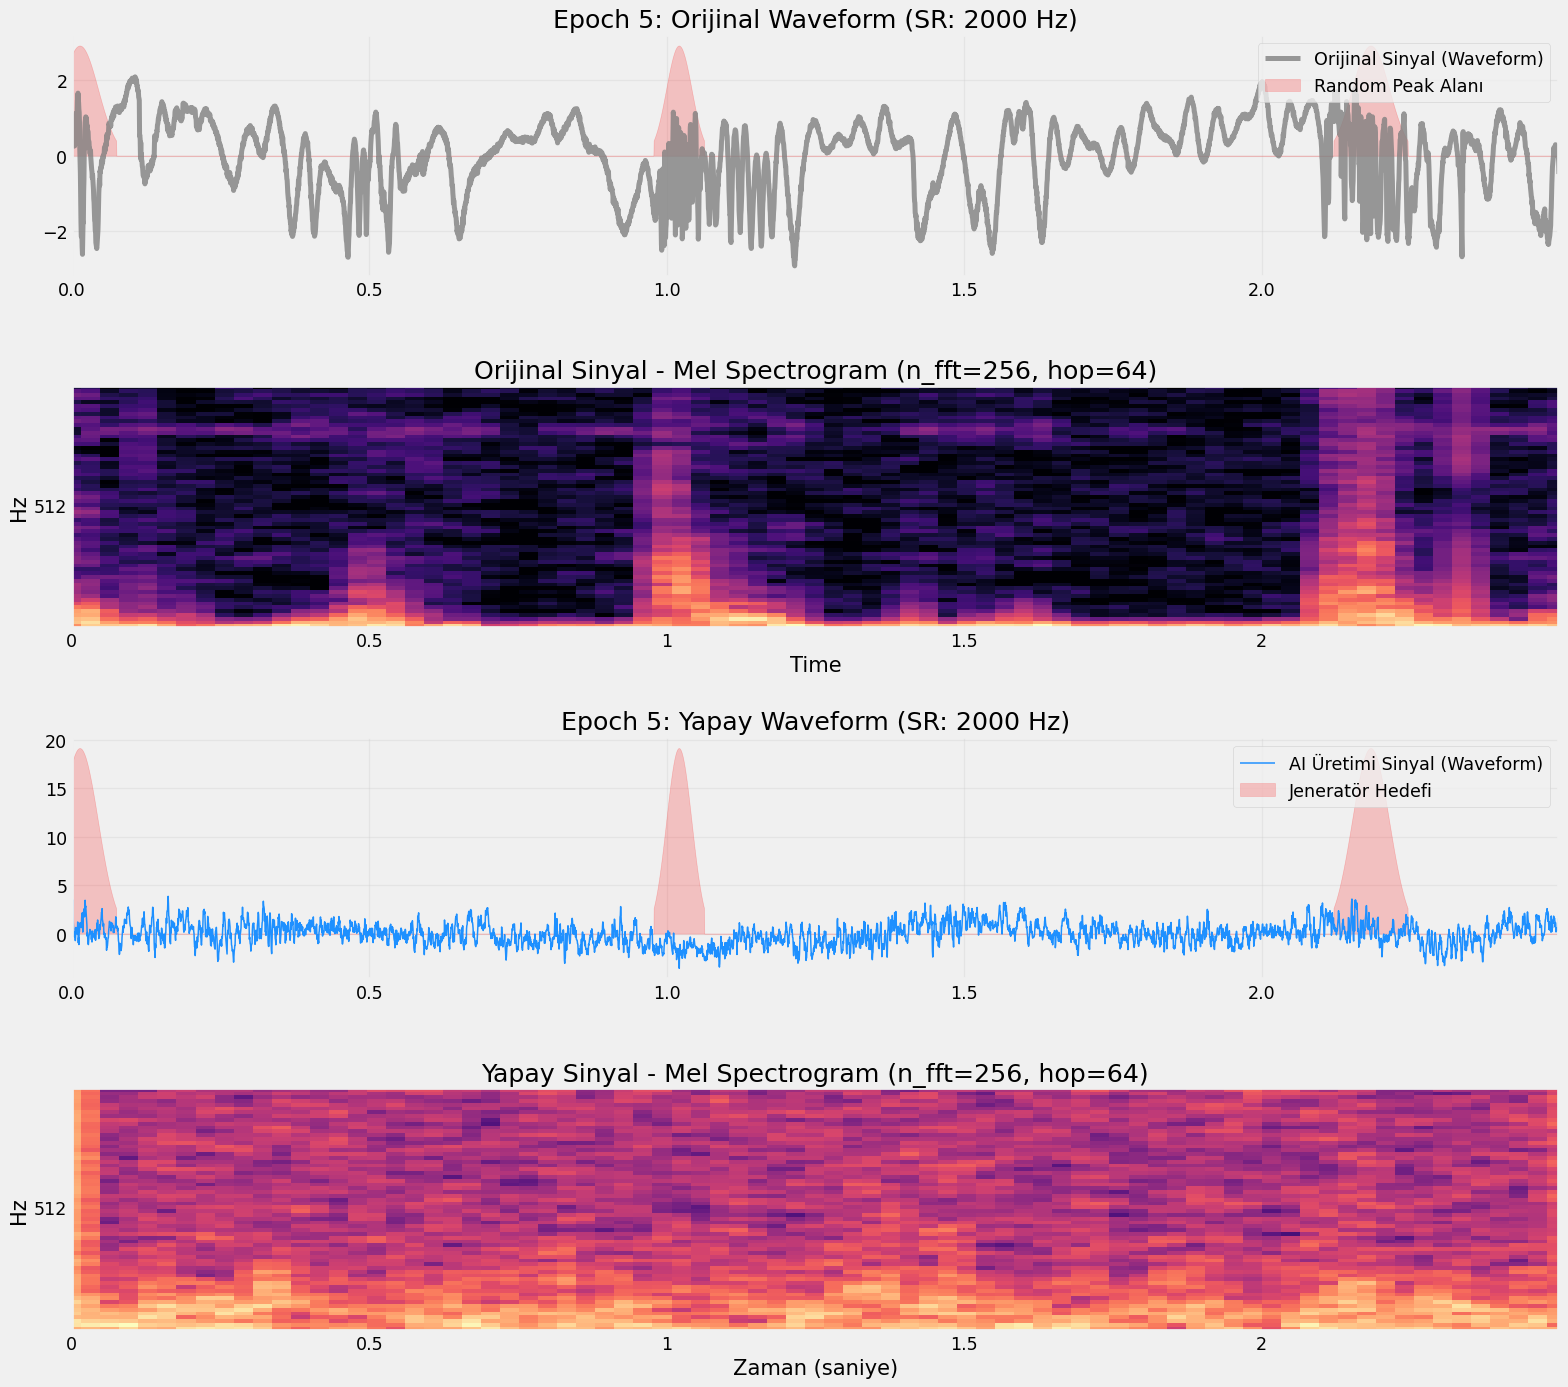

💾 Epoch 5 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 856/856 | Diffusion Loss (MSE): 0.0186
Epoch 6 Özet | Avg Diffusion Loss: 0.1130 | Süre: 177.7 sn
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 856/856 | Diffusion Loss (MSE): 0.0200
Epoch 7 Özet | Avg Diffusion Loss: 0.1097 | Süre: 177.9 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 7 - Loss: 0.1097)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 856/856 | Diffusion Loss (MSE): 0.0083
Epoch 8 Özet | Avg Diffusion Loss: 0.1108 | Süre: 178.1 sn
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 856/856 | Diffusion Loss (MSE): 0.6273
Epoch 9 Özet | Avg Diffusion Loss: 0.1111 | Süre: 178.3 sn
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 856/856 | Diffusion Loss (MSE): 0.1208
Epoch 10 Özet | Avg Diffusion Loss: 0.1127 | Süre: 178.1 sn
Epoch 10 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:53<00:00,  4.29it/s]


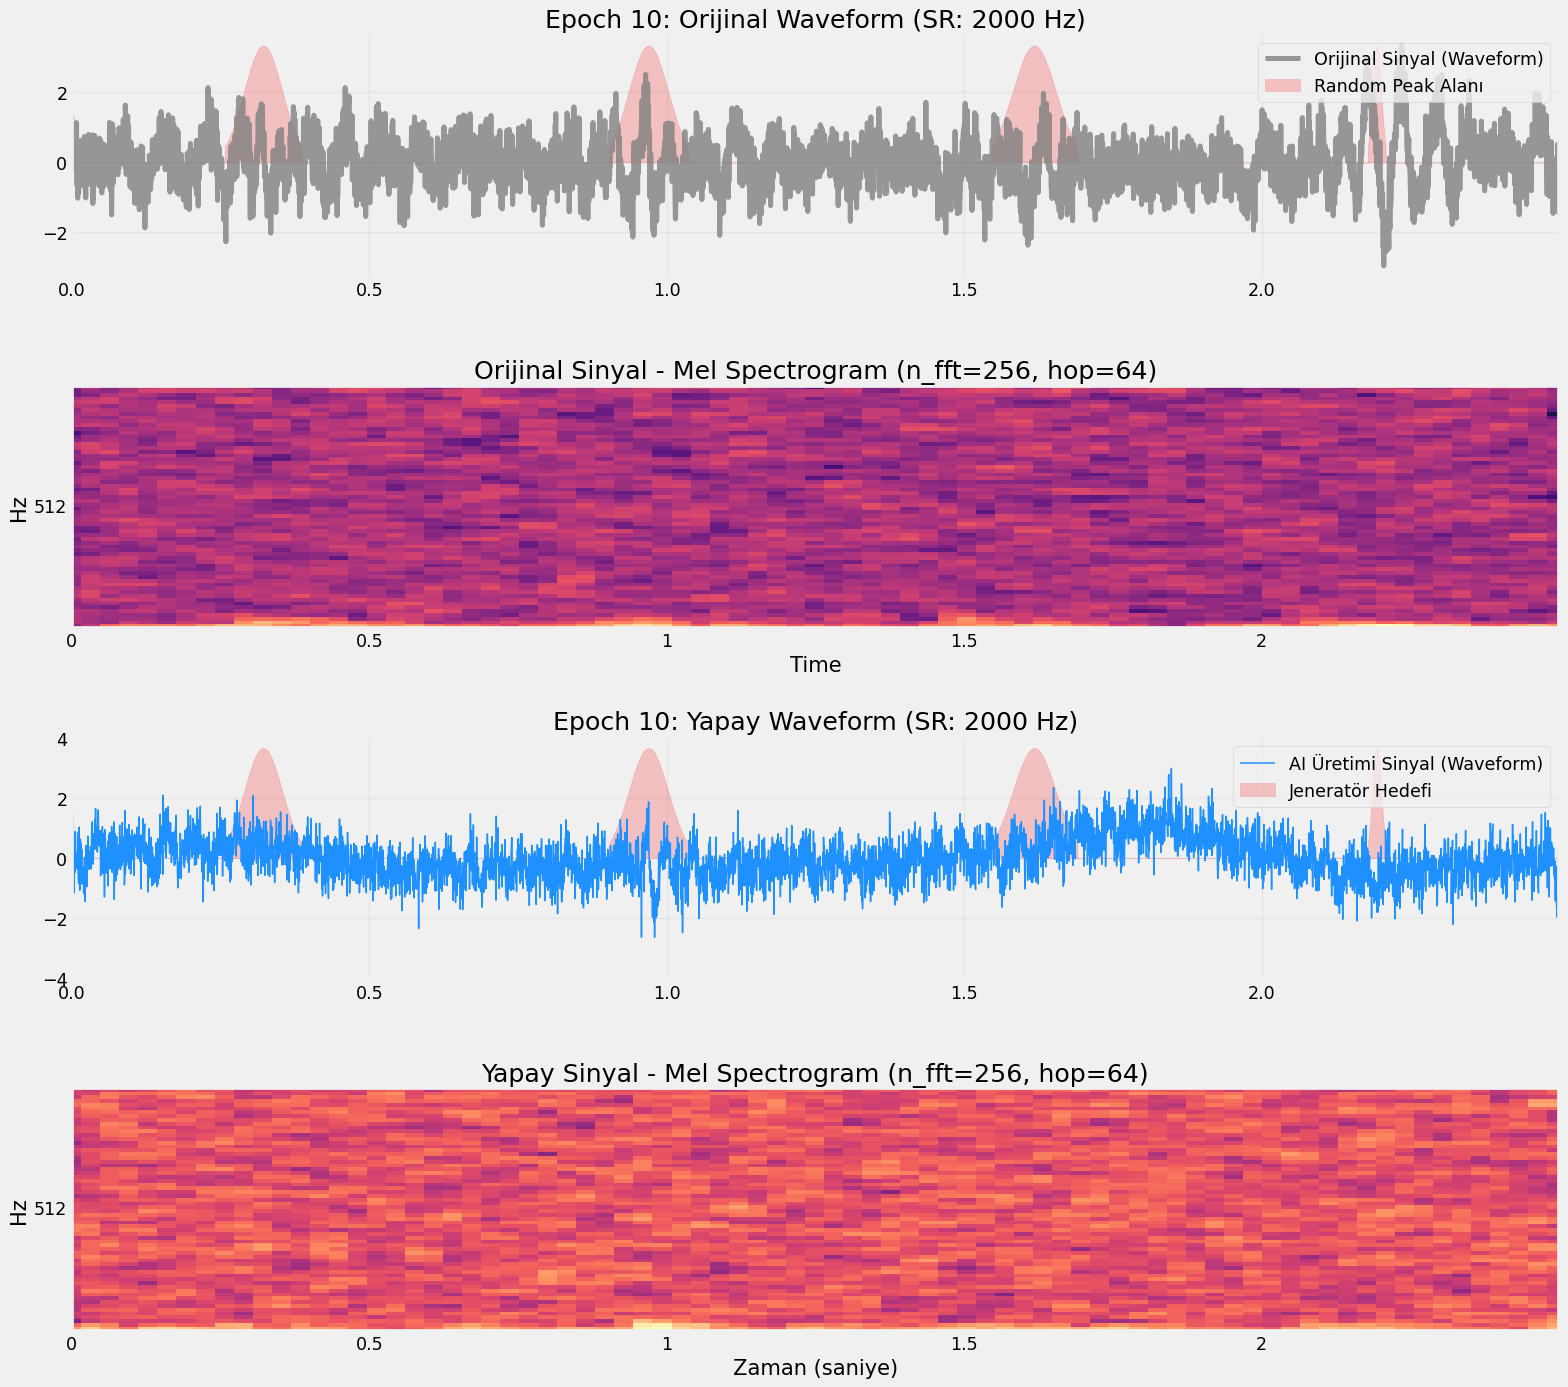

💾 Epoch 10 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 856/856 | Diffusion Loss (MSE): 0.0023
Epoch 11 Özet | Avg Diffusion Loss: 0.1070 | Süre: 177.8 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 11 - Loss: 0.1070)
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 856/856 | Diffusion Loss (MSE): 0.0107
Epoch 12 Özet | Avg Diffusion Loss: 0.1093 | Süre: 178.3 sn
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 856/856 | Diffusion Loss (MSE): 0.1353
Epoch 13 Özet | Avg Diffusion Loss: 0.1106 | Süre: 178.1 sn
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 856/856 | Diffusion Loss (MSE): 0.3867
Epoch 14 Özet | Avg Diffusion Loss: 0.1123 | Süre: 178.5 sn
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 856/856 | Diffusion Loss (MSE): 0.0106
Epoch 15 Özet | Avg Diffusion Loss: 0.1075 | Süre: 178.4 sn
Epoch 15 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:47<00:00,  4.39it/s]


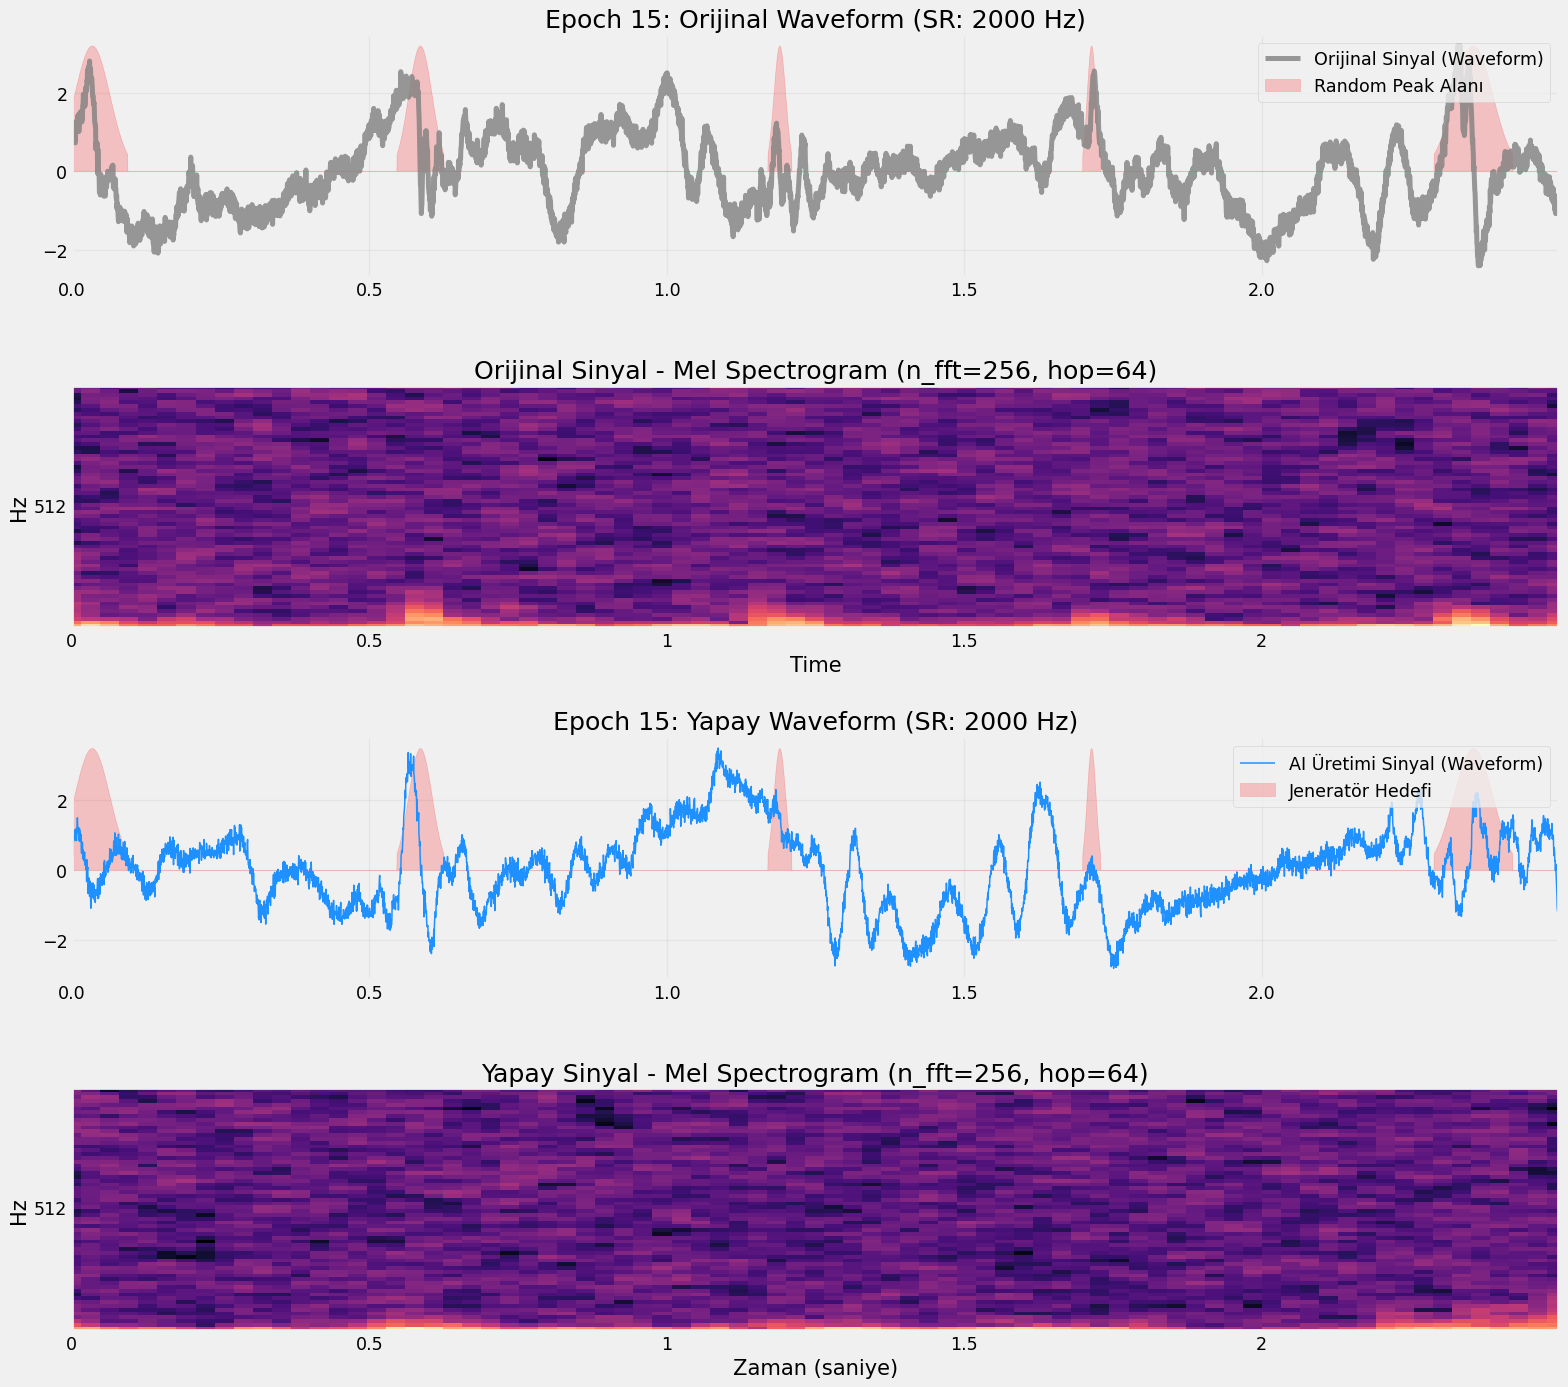

💾 Epoch 15 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 856/856 | Diffusion Loss (MSE): 0.0081
Epoch 16 Özet | Avg Diffusion Loss: 0.1092 | Süre: 177.8 sn
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 856/856 | Diffusion Loss (MSE): 0.0123
Epoch 17 Özet | Avg Diffusion Loss: 0.1110 | Süre: 178.1 sn
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 856/856 | Diffusion Loss (MSE): 0.0094
Epoch 18 Özet | Avg Diffusion Loss: 0.1084 | Süre: 178.2 sn
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 856/856 | Diffusion Loss (MSE): 0.0882
Epoch 19 Özet | Avg Diffusion Loss: 0.1072 | Süre: 178.2 sn
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 856/856 | Diffusion Loss (MSE): 0.0156
Epoch 20 Özet | Avg Diffusion Loss: 0.1071 | Süre: 178.6 sn
Epoch 20 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:54<00:00,  4.27it/s]


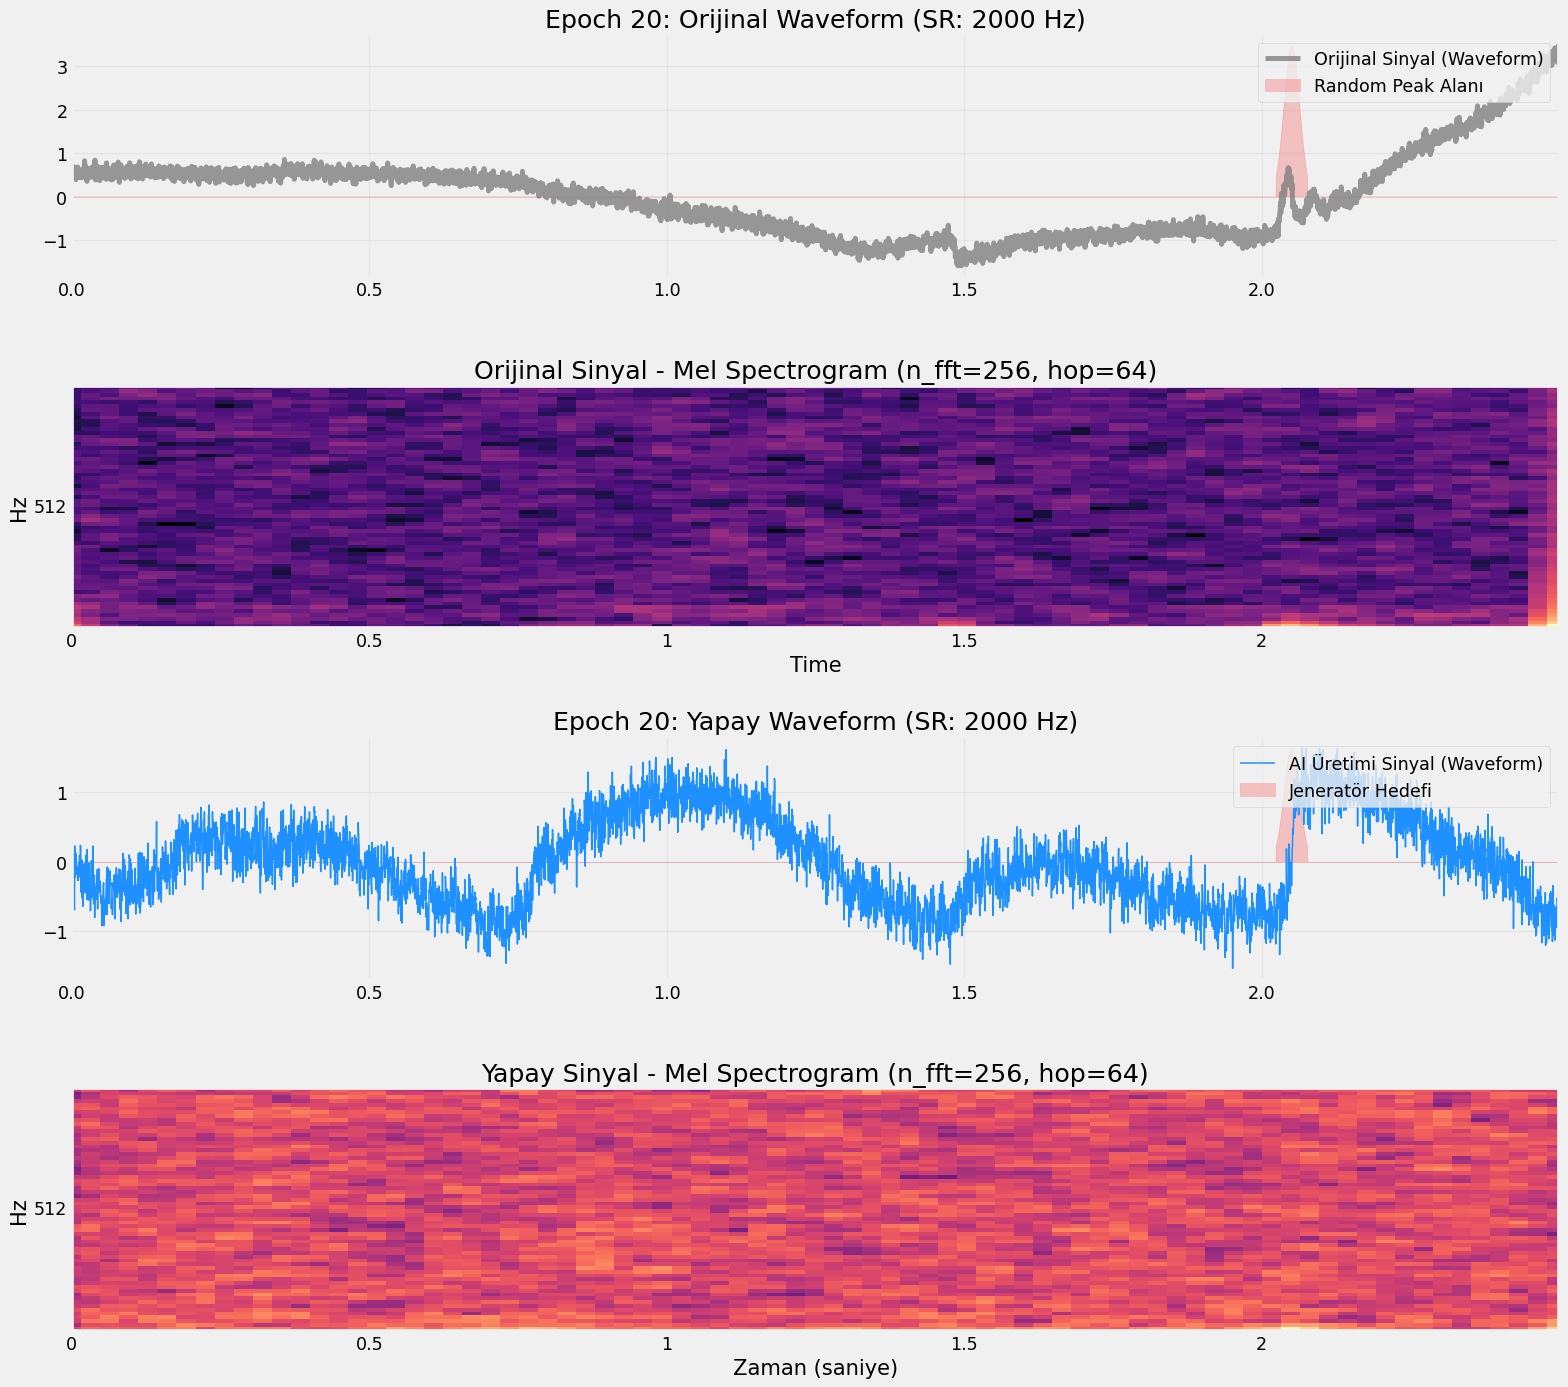

💾 Epoch 20 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 856/856 | Diffusion Loss (MSE): 0.0034
Epoch 21 Özet | Avg Diffusion Loss: 0.1058 | Süre: 178.1 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 21 - Loss: 0.1058)
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 856/856 | Diffusion Loss (MSE): 0.0802
Epoch 22 Özet | Avg Diffusion Loss: 0.1103 | Süre: 178.7 sn
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 856/856 | Diffusion Loss (MSE): 0.0025
Epoch 23 Özet | Avg Diffusion Loss: 0.1039 | Süre: 178.2 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 23 - Loss: 0.1039)
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 856/856 | Diffusion Loss (MSE): 0.0142
Epoch 24 Özet | Avg Diffusion Loss: 0.1075 | Süre: 178.4 sn
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 856/856 | Diffusion Loss (MSE): 0.0018
Epoch 25 Özet | Avg Diffusion Loss: 0.1111 | Süre: 178.3 sn
Epoch 25 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:49<00:00,  4.36it/s]


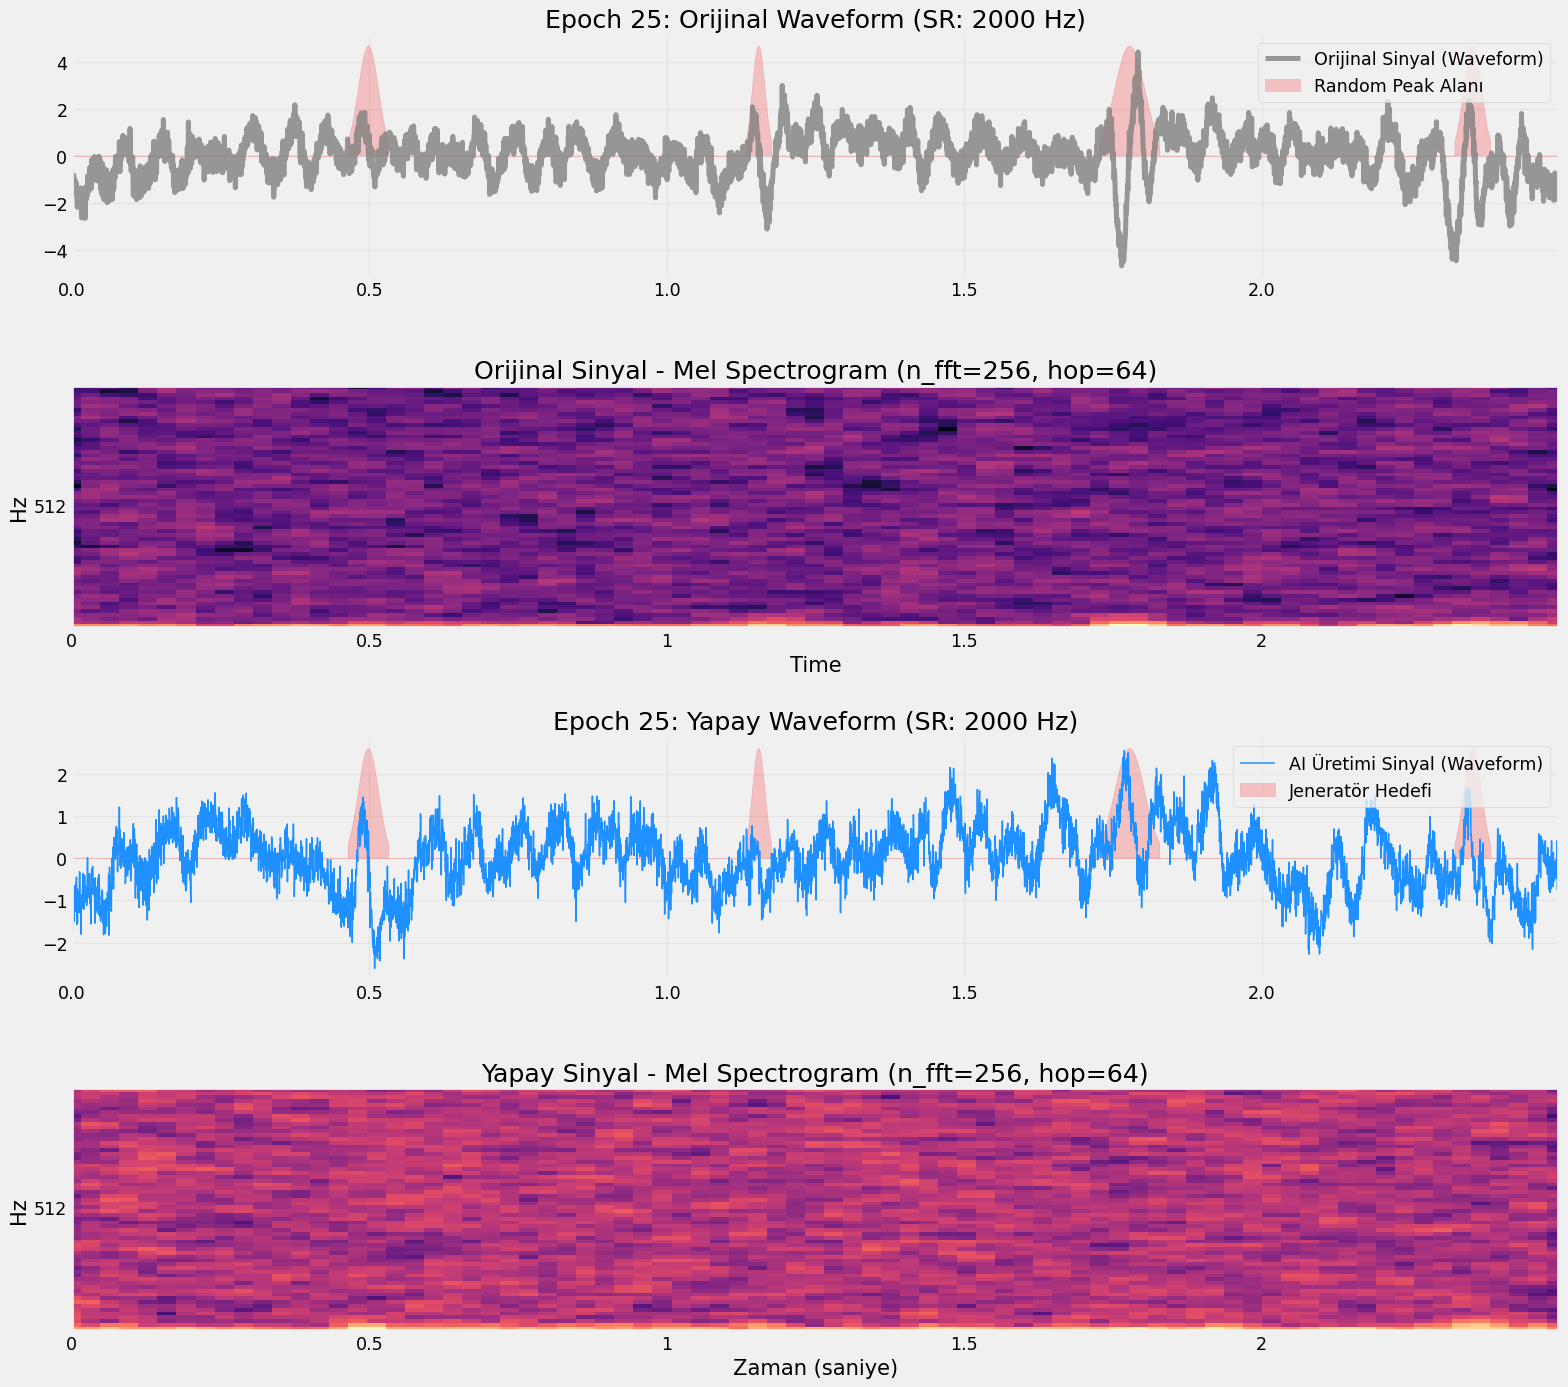

💾 Epoch 25 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 856/856 | Diffusion Loss (MSE): 0.0501
Epoch 26 Özet | Avg Diffusion Loss: 0.1078 | Süre: 178.1 sn
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 856/856 | Diffusion Loss (MSE): 0.0524
Epoch 27 Özet | Avg Diffusion Loss: 0.1076 | Süre: 178.1 sn
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 856/856 | Diffusion Loss (MSE): 0.0267
Epoch 28 Özet | Avg Diffusion Loss: 0.1077 | Süre: 178.9 sn
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 856/856 | Diffusion Loss (MSE): 0.1000
Epoch 29 Özet | Avg Diffusion Loss: 0.1049 | Süre: 178.4 sn
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 856/856 | Diffusion Loss (MSE): 0.0205
Epoch 30 Özet | Avg Diffusion Loss: 0.1040 | Süre: 178.7 sn
Epoch 30 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:50<00:00,  4.34it/s]


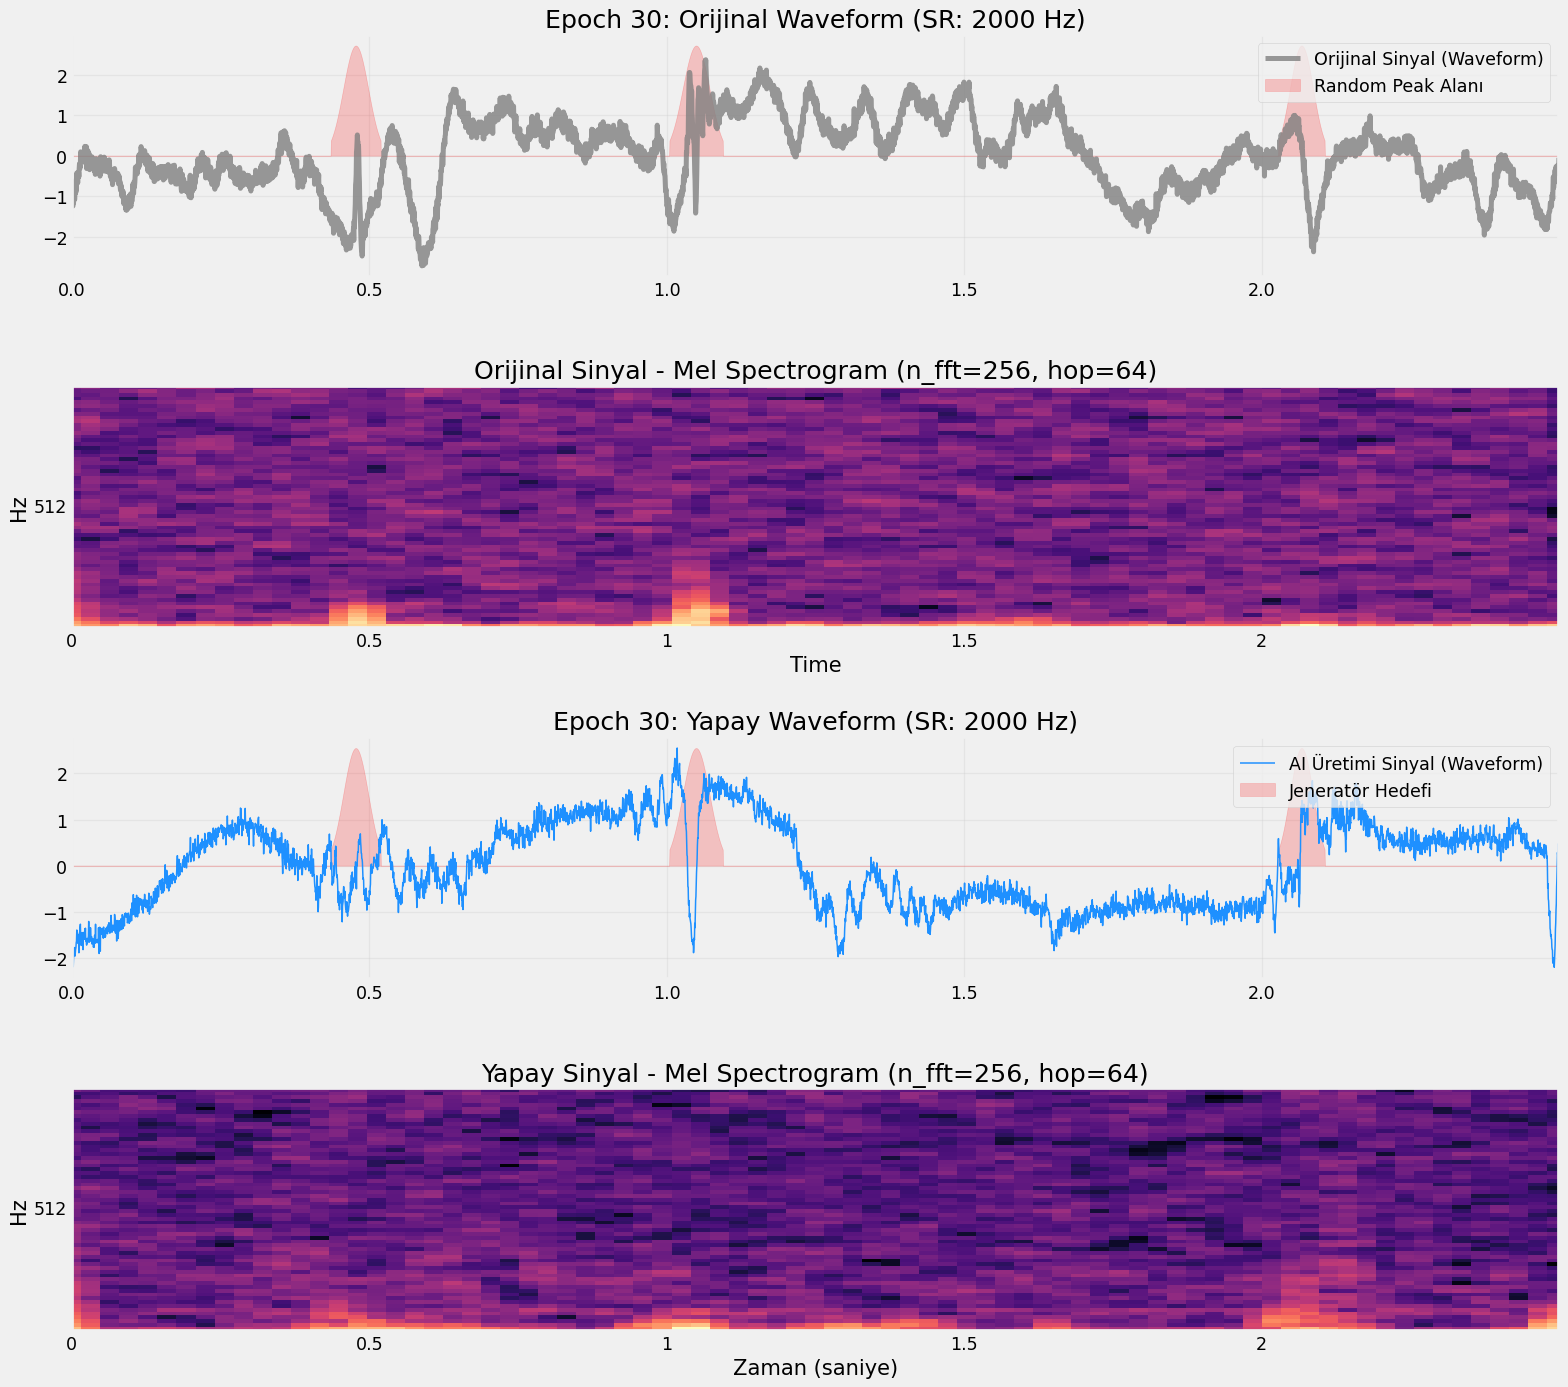

💾 Epoch 30 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 856/856 | Diffusion Loss (MSE): 0.0158
Epoch 31 Özet | Avg Diffusion Loss: 0.1073 | Süre: 178.1 sn
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 856/856 | Diffusion Loss (MSE): 0.0054
Epoch 32 Özet | Avg Diffusion Loss: 0.1086 | Süre: 178.0 sn
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 856/856 | Diffusion Loss (MSE): 0.0073
Epoch 33 Özet | Avg Diffusion Loss: 0.1059 | Süre: 178.6 sn
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 856/856 | Diffusion Loss (MSE): 0.0062
Epoch 34 Özet | Avg Diffusion Loss: 0.1056 | Süre: 178.3 sn
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 856/856 | Diffusion Loss (MSE): 0.0072
Epoch 35 Özet | Avg Diffusion Loss: 0.1043 | Süre: 178.3 sn
Epoch 35 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:50<00:00,  4.33it/s]


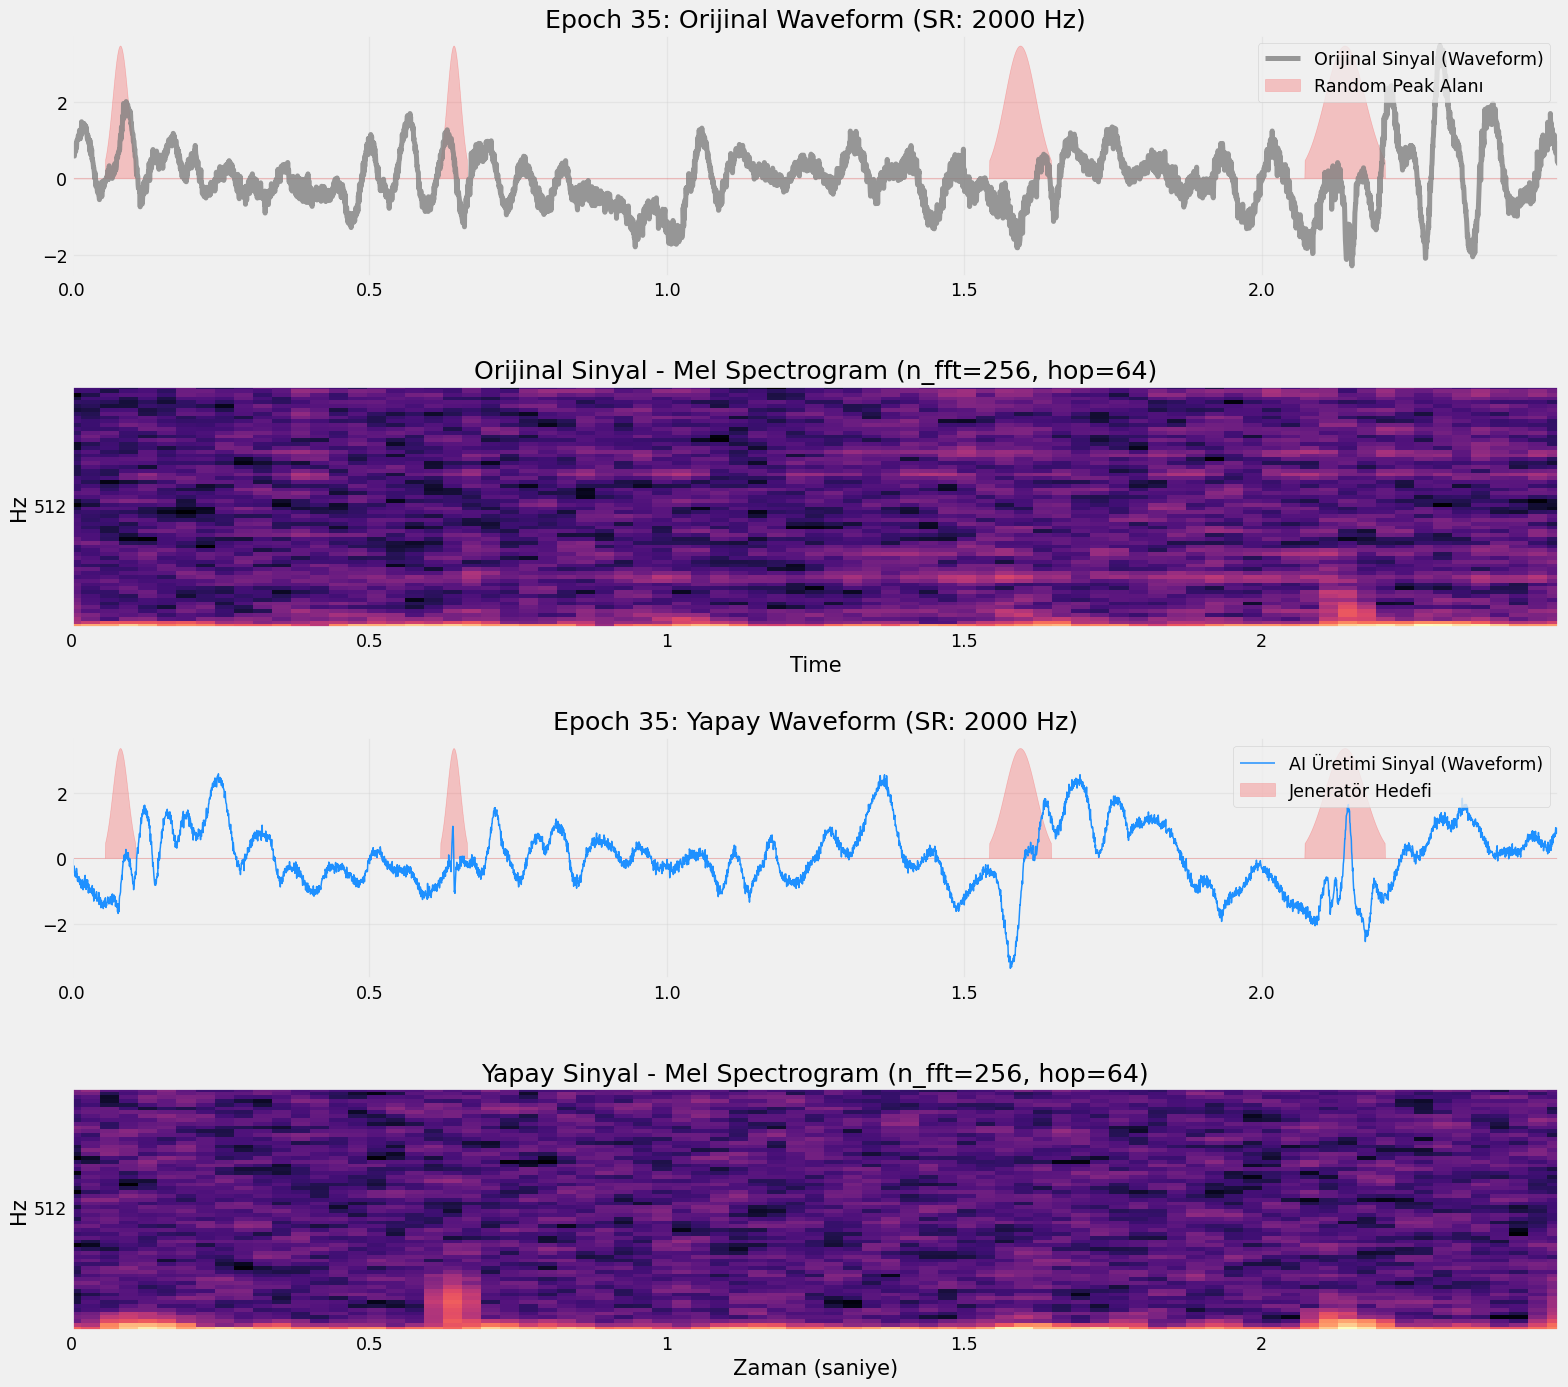

💾 Epoch 35 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 856/856 | Diffusion Loss (MSE): 0.0751
Epoch 36 Özet | Avg Diffusion Loss: 0.1056 | Süre: 178.1 sn
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 856/856 | Diffusion Loss (MSE): 0.0069
Epoch 37 Özet | Avg Diffusion Loss: 0.1062 | Süre: 178.2 sn
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 856/856 | Diffusion Loss (MSE): 0.0235
Epoch 38 Özet | Avg Diffusion Loss: 0.1079 | Süre: 178.2 sn
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 856/856 | Diffusion Loss (MSE): 0.0408
Epoch 39 Özet | Avg Diffusion Loss: 0.1063 | Süre: 178.3 sn
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 856/856 | Diffusion Loss (MSE): 0.1519
Epoch 40 Özet | Avg Diffusion Loss: 0.1087 | Süre: 178.3 sn
Epoch 40 için sinyal sentezleniyor (Difüzyon: 1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:51<00:00,  4.32it/s]


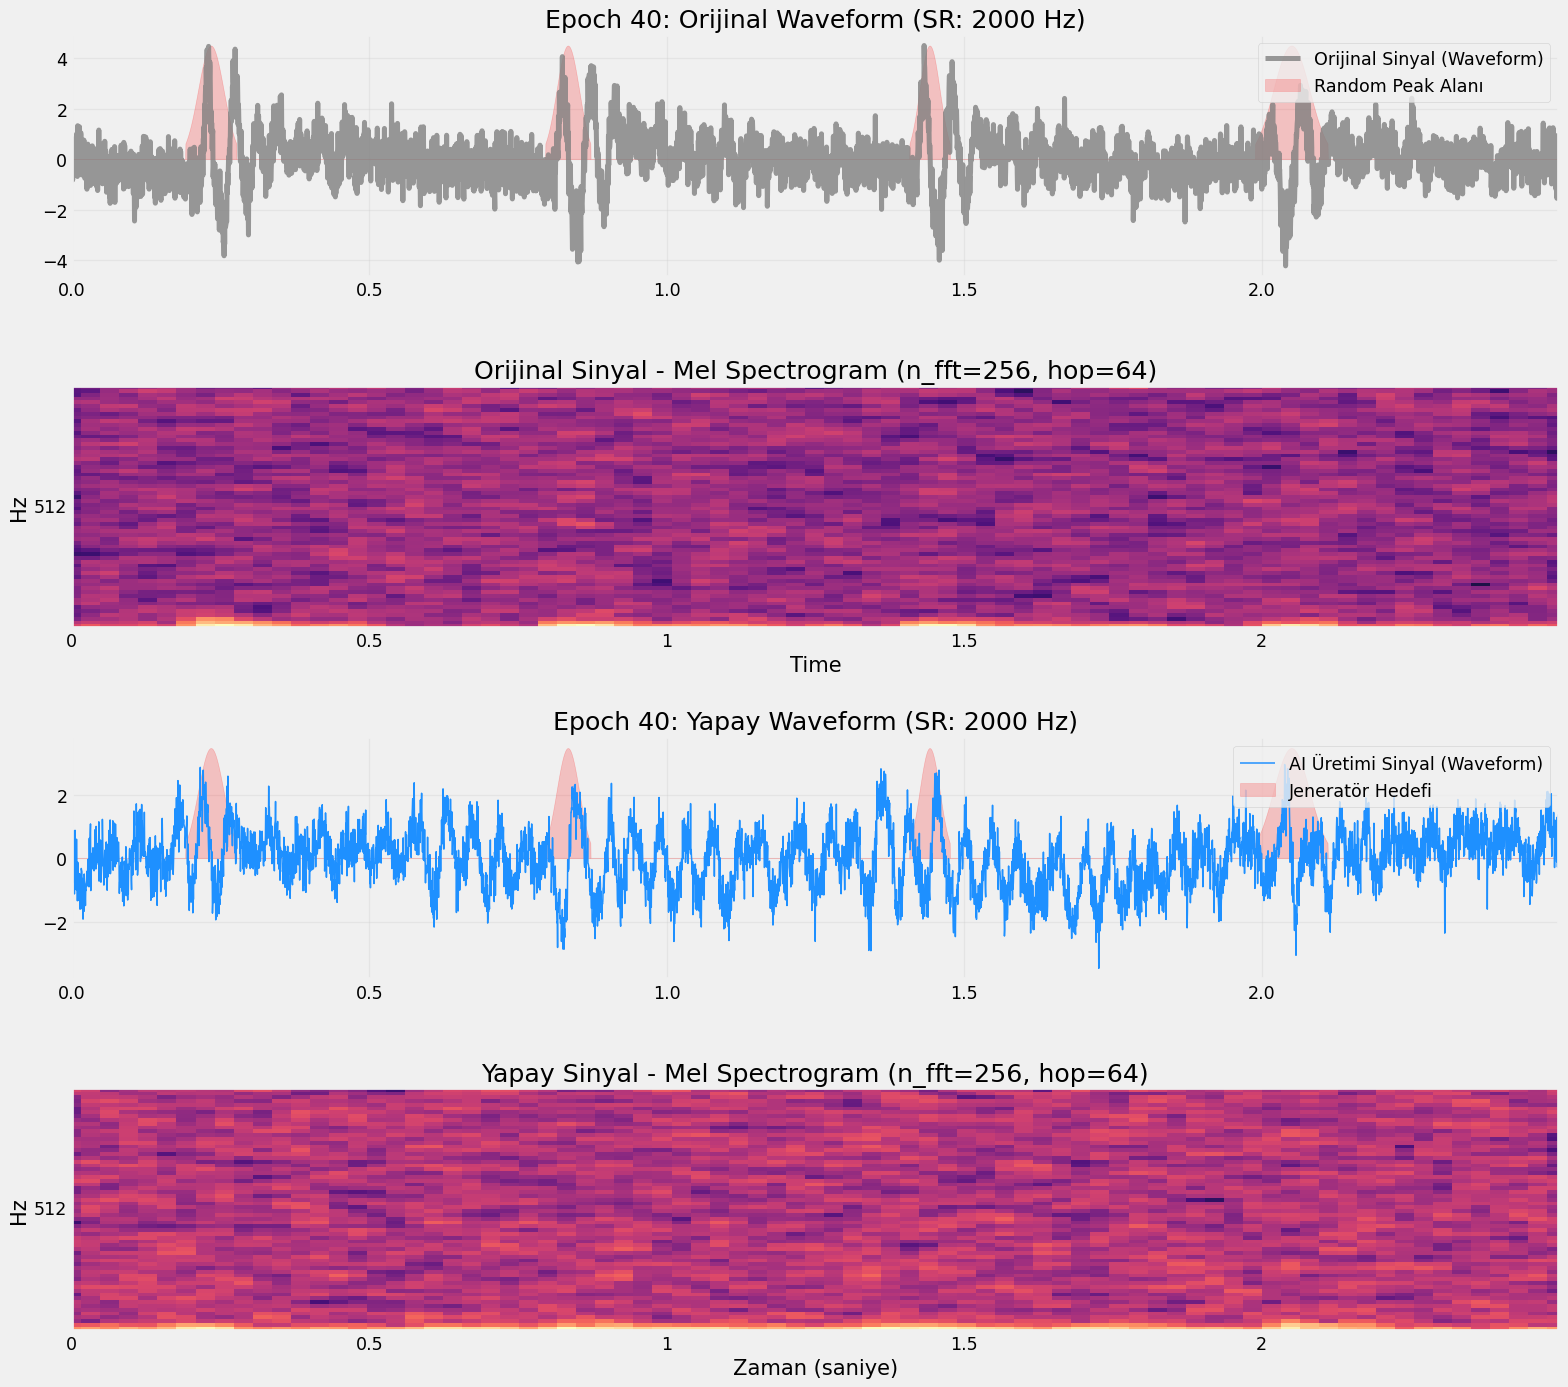

💾 Epoch 40 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 413/856 | Diffusion Loss (MSE): 0.1626

In [ ]:
import time
import tensorflow as tf
import os

EPOCHS = 500
best_diff_loss = float('inf') # Artık sadece Difüzyon (Gürültü Tahmini) kaybını takip ediyoruz
best_epoch_num = 0

# Weights klasörünün var olduğundan emin ol
weights_dir = os.path.join(MODEL_FOLDER, "weights")
os.makedirs(weights_dir, exist_ok=True)

for epoch in range(EPOCHS):
    start = time.time()
    
    # Sadece tek bir loss listesi açıyoruz
    epoch_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        enc_masks = tf.convert_to_tensor(batch_data[:, :, 2:3], dtype=tf.float32)
        
        # Train Step artık sadece tek bir MSE loss döndürüyor
        loss = train_step(real_sigs, peaks, enc_masks)
        
        epoch_loss.append(loss)
        
        print(f"Epoch {epoch+1} | Step {step+1}/{total_steps} | Diffusion Loss (MSE): {loss:.4f}", end='\r', flush=True)

    # Epoch ortalaması
    avg_loss = tf.reduce_mean(epoch_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | Avg Diffusion Loss: {avg_loss:.4f} | Süre: {time.time() - start:.1f} sn")
    
    # BEST EPOCH TAKİBİ (Düşük MSE = İyi Gürültü Tahmini)
    if avg_loss < best_diff_loss:
        best_diff_loss = avg_loss
        best_epoch_num = epoch + 1
        print(f"🌟 Yeni En İyi Başarı! (Best Epoch şu an: {best_epoch_num} - Loss: {best_diff_loss:.4f})")

    # HER 5 EPOCH'TA BİR: ÇİZİM YAP VE AĞIRLIKLARI KAYDET
    if (epoch + 1) % 5 == 0:
        # 1. Çizimi model klasörüne kaydet (generator yerine diffusion_unet gönderiyoruz)
        visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, MODEL_FOLDER)
        
        # 2. Ağırlıkları (weights) kaydet
        enc_weight_path = os.path.join(weights_dir, f"encoder_epoch_{epoch+1}.weights.h5")
        unet_weight_path = os.path.join(weights_dir, f"diffusion_unet_epoch_{epoch+1}.weights.h5")
        
        encoder.save_weights(enc_weight_path)
        diffusion_unet.save_weights(unet_weight_path) # generator.save_weights yerine u-net
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları başarıyla kaydedildi.")

print(f"\n✅ EĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")